In [174]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [175]:
import sys
sys.path.append("../")
import torch
import numpy as np
import pandas as pd
import gudhi as gd
from gudhi.representations import Silhouette
from utils.generate import gen_covariate, gen_trt_prob
import matplotlib.pyplot as plt
import pickle
from torch_geometric.utils.smiles import from_rdmol
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from estimators import ipw_estimator, plugin_estimator, aipw_estimator
from utils.utils import numerical_integration, fit_functional_regression
from scipy.stats import gaussian_kde
import random

# Load data and transform to graph structure

In [176]:
with open('./data/val_data.pickle', 'rb') as f:
    dataset = pickle.load(f)

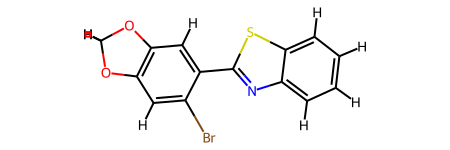

In [177]:
random.seed(42)

i = 0   # ith conformer
graph_dataset = []

for data in dataset:
    try:
        graph = from_rdmol(data[1][i])  # transform to torch_geometric Data type graph
    except:
        continue
    
    # extract node position
    conformer = data[1][0].GetConformer()
    node_coord = []
    for j in range(graph.num_nodes):
        pos = conformer.GetAtomPosition(j)
        node_coord.append([pos.x, pos.y])

    # insert node position
    pos = torch.tensor(node_coord)
    
    # center graph to 0
    centered_pos = pos - torch.mean(pos, dim=0)
    
    # standardize such that max norm is 1
    l2_norm = torch.sqrt(torch.sum(centered_pos**2, axis=1))
    std_pos = centered_pos / l2_norm.max()

    # insert position
    graph.pos = std_pos

    # collect graphs
    graph_dataset.append(graph)

dataset[1][1][i]

# Transform to silhouette

In [178]:
interval = [0, 8.5]
r = 1
resolution = 100

def power_weight(point, r=3):
    birth, death = point
    return np.abs(death - birth)**r

silhouette = Silhouette(weight=lambda x: power_weight(x, r), resolution=resolution, sample_range=interval, keep_endpoints=True)

In [180]:
torch.manual_seed(42)
np.random.seed(42)

loop1, loop2 = 1, 2     # collect data with corresponding number of loops
tseq=np.linspace(*interval, resolution)
n_samples_dict = {loop1:0, loop2:0}     # dictionary to count number of samples with 0 and 2 loops

phi0_list = [[], []]    # store silhouettes of 0-dim homology features for 1 and 3 loops
phi1_list = [[], []]    # store silhouettes of 1-dim homology features for 1 and 3 loops
for data in graph_dataset:
    st = gd.SimplexTree()

    # assign node weights as the weighted mean of node features
    w = torch.softmax(torch.rand(*data.x.shape), dim=1) # random weights for each node feature (sums to 1)
    node_weights = (data.x * w).sum(dim=1)              # weighted sum of node features to get a single weight for each node

    # insert node filtration values
    for node in range(data.num_nodes):
        st.insert([node], filtration=node_weights[node].item())

    for edge in range(data.num_edges):
        nodes = data.edge_index[:, edge]    # nodes connected to the given edge
        edge_weight = node_weights[nodes].max().item()
        st.insert(nodes.tolist(), filtration=edge_weight)

    # collect silhouettes
    st.compute_persistence(persistence_dim_max=True)
    diag0 = st.persistence_intervals_in_dimension(0)
    diag1 = st.persistence_intervals_in_dimension(1)
    n_loops = len(diag1)                # number of 1-dimensional homology features (loops)
    if n_loops == loop1 or n_loops == loop2:    # collect diagrams of only "loop1" and "loop2" number of loops
        n_samples_dict[n_loops] += 1
        diag0[:, 1] = np.where(diag0[:, 1] == np.inf, 8.5, diag0[:, 1])   # replace inf with maximum filtration value
        diag1[:, 1] = np.where(diag1[:, 1] == np.inf, np.random.uniform(6.5, 8.5, 1), diag1[:, 1])   # replace inf with maximum filtration value
        if n_loops == loop1:
            phi0_list[0].append(silhouette.fit_transform([diag0]))
            phi1_list[0].append(silhouette.fit_transform([diag1]))
        else:
            phi0_list[1].append(silhouette.fit_transform([diag0]))
            phi1_list[1].append(silhouette.fit_transform([diag1]))

# Generate potential outcome pair $(Y^0, Y^1)$

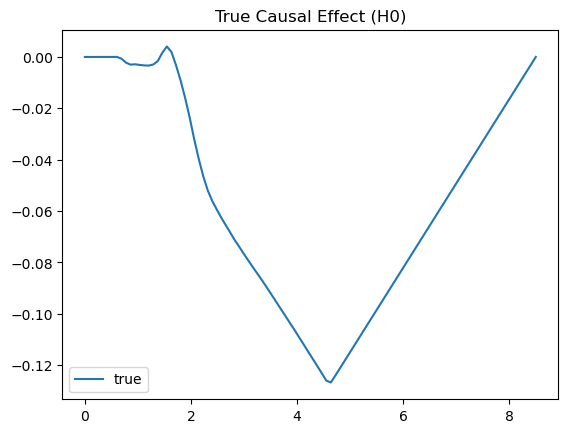

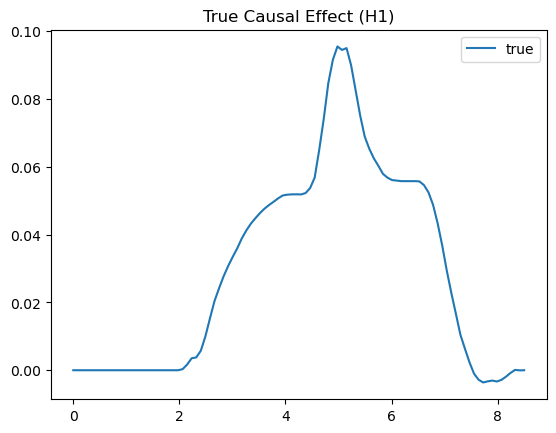

In [183]:
np.random.seed(42)

n = 1000      # number of potential outcome pairs
p = 0.75

idx0 = np.random.choice(range(len(phi0_list[0])), int(n * (2-p)))
idx1 = np.random.choice(range(len(phi0_list[1])), int(n * p))

# 0 hom dim
potential_trt0 = np.vstack([np.stack(phi0_list[1])[idx1], np.stack(phi0_list[0])[idx0[n:]]])   # shape [n, 1, resolution]
potential_ctrl0 = np.stack(phi0_list[0])[idx0[:n]]                  # shape [n, n_hom, resolution]
potential_outcomes0 = np.stack([potential_ctrl0, potential_trt0], axis=1)   # shape [n, 2, 1, resolution]

# 1 hom dim
potential_trt1 = np.vstack([np.stack(phi1_list[1])[idx1], np.stack(phi1_list[0])[idx0[n:]]])   # shape [n, 1, resolution]
potential_ctrl1 = np.stack(phi1_list[0])[idx0[:n]]                  # shape [n, 1, resolution]
potential_outcomes1 = np.stack([potential_ctrl1, potential_trt1], axis=1)   # shape [n, 2, 1, resolution]

potential_outcomes = np.concat([potential_outcomes0, potential_outcomes1], axis=2)   # shape [n, 2, n_hom, resolution] where n_hom is number of homology dimensions considered (2 in this case)

# true counterfactual treatment effect silhouette
true_effect = np.mean(potential_outcomes[:,1], axis=0) - np.mean(potential_outcomes[:,0], axis=0)   # shape [n_hom, resolution]
# 0-dim homology features
plt.plot(tseq, true_effect[0], label="true")
plt.legend()
plt.title("True Causal Effect (H0)")
plt.show();
# 1-dim homology features
plt.plot(tseq, true_effect[1], label="true")
plt.legend()
plt.title("True Causal Effect (H1)")
plt.show();

# Data generating process and treatment mechanism

Number of treated samples: 505, Number of non-treated samples: 495
Max propensity: 0.933445, Min propensity: 0.028105


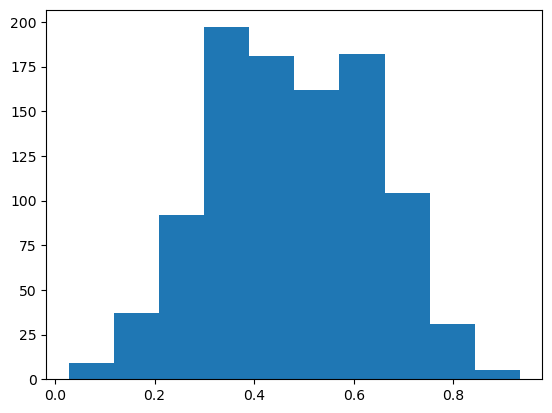

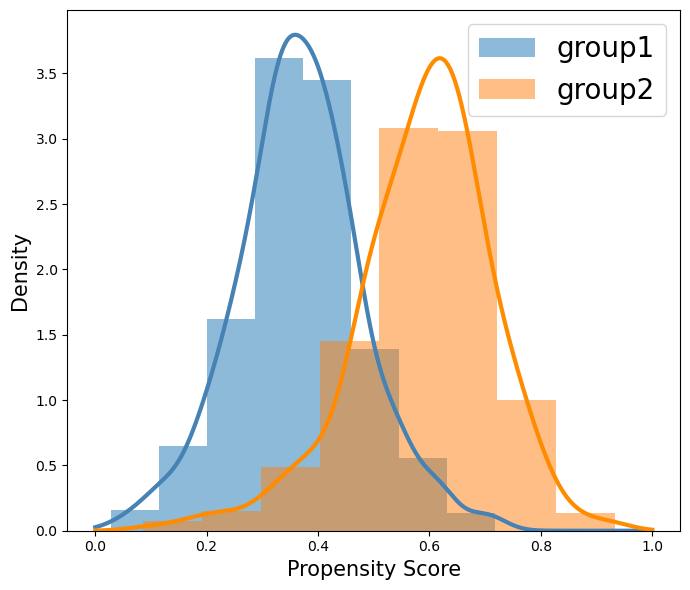

In [184]:
np.random.seed(42)
n_cov = 5

# Data generating process
mu1 = np.array([1, 0.6, -0.7, 2.2, -1])     # mean vector of covariates subgroup 1
mu2 = np.array([0.4, -0.4, -0.6, 3.3, 3])   # mean vector of covariates subgroup 2
Sigma = np.eye(n_cov) * .5
covariate1, covariate2, covariate = gen_covariate(mu1, mu2, Sigma, n)   # generate covariates

# Treatment process
beta = np.array([-0.5, -0.1, 0.6, 0.1, 0.1])   
prob, A = gen_trt_prob(covariate, beta)     # generate treatment

# construct observed data
observed_data = (potential_outcomes[range(n), A], A, covariate)    # (phi, A, X)

# histogram of entire dataset
print(f"Number of treated samples: {(A==1).sum()}, Number of non-treated samples: {(A==0).sum()}")
print(f"Max propensity: {prob.max():.6f}, Min propensity: {prob.min():.6f}")
plt.hist(prob)
plt.show();

# histogram of each subgroup
plt.figure(figsize=(7,6))
group1_prob, _ = gen_trt_prob(covariate1, beta)
group2_prob, _ = gen_trt_prob(covariate2, beta)
plt.hist(group1_prob, label="group1", alpha=0.5, density=True, bins=8)
plt.hist(group2_prob, label="group2", alpha=0.5, density=True, bins=8)
kde = gaussian_kde(group1_prob)
kde2 = gaussian_kde(group2_prob)
x_range = np.linspace(0, 1, 1000)
plt.plot(x_range, kde(x_range), c="steelblue", lw=3)
plt.plot(x_range, kde2(x_range), c="darkorange", lw=3)
# plt.title("Density of true propensity score", size=30)
plt.xlabel("Propensity Score", size=15)
plt.ylabel("Density", size=15)
plt.legend(prop={"size":20})
plt.tight_layout()
plt.show();

# Estimation

In [185]:
# sample split (one sample for fitting nuisance function and the other for estimation)
phi1, phi2, A1, A2, X1, X2 = train_test_split(*observed_data, test_size=0.5, random_state=0, stratify=observed_data[1])   # stratify on A
sample1 = (phi1, A1, X1)
sample2 = (phi2, A2, X2)

## Repeat experiment 20 times

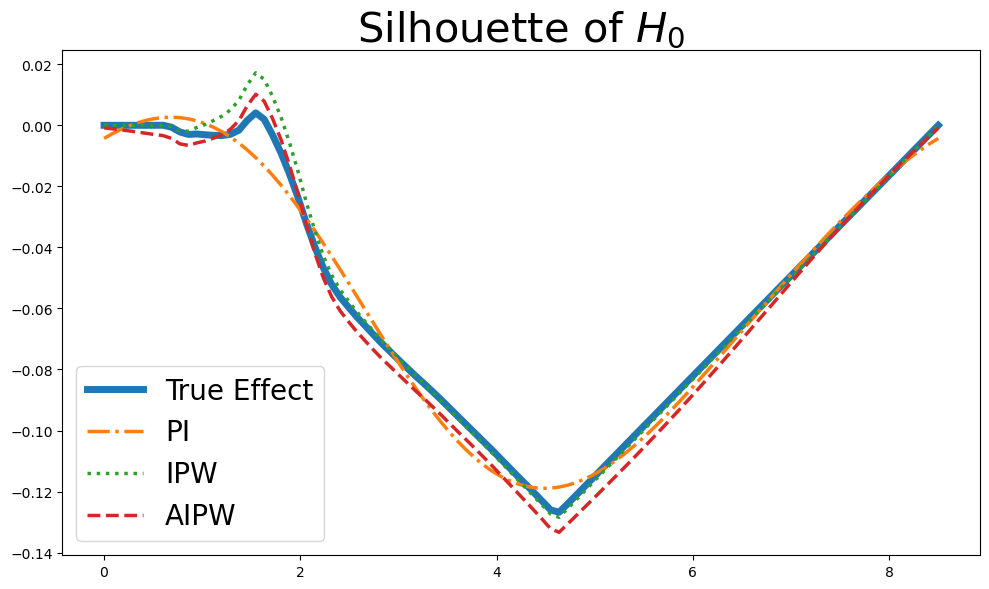

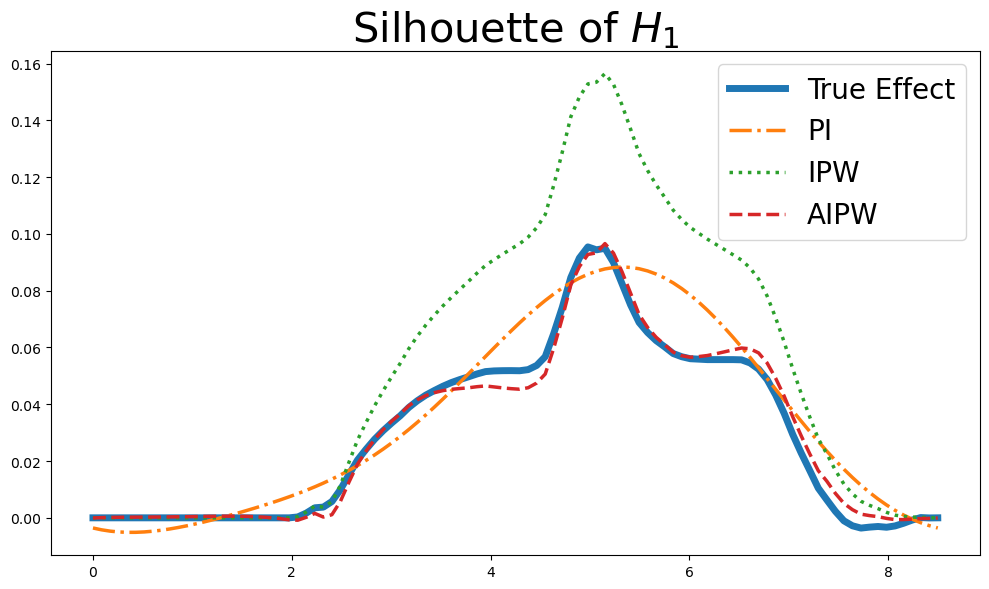

In [186]:
np.random.seed(42)

n_iter = 20
n_basis = 5

plugin0_list, ipw0_list, aipw0_list = [], [], []
plugin1_list, ipw1_list, aipw1_list = [], [], []

for i in range(n_iter):
    _, _, covariate = gen_covariate(mu1, mu2, Sigma, n) # generate covariates
    prob, A = gen_trt_prob(covariate, beta)                # generate treatment
    
    # among those assigned to Y^1, 75% were data of non-infected and 25% were data of infected
    # change order of data such that the data of infected assigned to Y^1 have a higher probability of receiving treatment (makes estimation more challenging)
    size = int(n/2)
    subgroup2_idx = prob[-(n-size):].argsort() + size
    idx = np.concatenate([np.arange(int(size)), subgroup2_idx[-(n-size):]])
    covariate = covariate[idx]
    A = A[idx]
    observed_data = (potential_outcomes[range(n), A], A, covariate) # construct observed data

    # sample split
    phi1, phi2, A1, A2, X1, X2 = train_test_split(*observed_data, test_size=0.5, random_state=0, stratify=observed_data[1])   # stratify on A
    sample1 = (phi1, A1, X1)
    sample2 = (phi2, A2, X2)

    # plug-in
    # fit on sample 1, estimate on sample 2
    reg1 = fit_functional_regression((phi1, A1, X1), tseq, n_basis=n_basis)
    mu_hats1= [(mu0.predict(pd.DataFrame(X2))(tseq).squeeze(), mu1.predict(pd.DataFrame(X2))(tseq).squeeze()) for mu0, mu1 in reg1]
    plugin10, plugin11 = plugin_estimator(mu_hats1)
    # fit on sample 2, estimate on sample 1
    reg2 = fit_functional_regression((phi2, A2, X2), tseq, n_basis=n_basis)
    mu_hats2 = [(mu0.predict(pd.DataFrame(X1))(tseq).squeeze(), mu1.predict(pd.DataFrame(X1))(tseq).squeeze()) for mu0, mu1 in reg2]
    plugin20, plugin21 = plugin_estimator(mu_hats2)
    # average
    plugin0 = (plugin10 + plugin20) / 2  # homology dim 0
    plugin0_list.append(plugin0)
    plugin1 = (plugin11 + plugin21) / 2  # homology dim 1
    plugin1_list.append(plugin1)

    # ipw
    # fit on sample 1, estimate on sample 2
    pi_hat1 = RandomForestClassifier().fit(X1, A1).predict_proba(X2)[:,1]
    ipw10, ipw11 = ipw_estimator(pi_hat1, (phi2, A2, X2))
    # fit on sample 2, estimate on sample 1
    pi_hat2 = RandomForestClassifier().fit(X2, A2).predict_proba(X1)[:,1]
    ipw20, ipw21 = ipw_estimator(pi_hat2, (phi1, A1, X1))
    # average
    ipw0 = (ipw10 + ipw20) / 2  # homology dim 0
    ipw0_list.append(ipw0)
    ipw1 = (ipw11 + ipw21) / 2  # homology dim 1
    ipw1_list.append(ipw1)

    # aipw
    # fit on sample 1, estimate on sample 2
    aipw10, aipw11 = aipw_estimator(pi_hat1, mu_hats1, (phi2, A2, X2))
    # fit on sample 2, estimate on sample 1
    aipw20, aipw21 = aipw_estimator(pi_hat2, mu_hats2, (phi1, A1, X1))
    # average
    aipw0 = (aipw10 + aipw20) / 2     # homology dim 0
    aipw0_list.append(aipw0)
    aipw1 = (aipw11 + aipw21) / 2     # homology dim 1
    aipw1_list.append(aipw1)


# plot
lw = 2.5

# plot H0
ipw0_avg = np.array(ipw0_list).mean(axis=0)
ipw0_std = np.array(ipw0_list).std(axis=0)
pi0_avg = np.array(plugin0_list).mean(axis=0)
pi0_std = np.array(plugin0_list).std(axis=0)
aipw0_avg = np.array(aipw0_list).mean(axis=0)
aipw0_std = np.array(aipw0_list).std(axis=0)

plt.figure(figsize=(10,6))
plt.plot(tseq, true_effect[0], label="True Effect", lw=2*lw)
plt.plot(tseq, pi0_avg, label="PI", ls="-.", lw=lw)
plt.plot(tseq, ipw0_avg, label="IPW", ls=":", lw=lw)
plt.plot(tseq, aipw0_avg, label="AIPW", ls="--", lw=lw)
# plt.ylim(-0.15, 0.02)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_0$", size=30)
plt.tight_layout()
plt.show();

# plot H1
ipw1_avg = np.array(ipw1_list).mean(axis=0)
ipw1_std = np.array(ipw1_list).std(axis=0)
pi1_avg = np.array(plugin1_list).mean(axis=0)
pi1_std = np.array(plugin1_list).std(axis=0)
aipw1_avg = np.array(aipw1_list).mean(axis=0)
aipw1_std = np.array(aipw1_list).std(axis=0)

plt.figure(figsize=(10,6))
plt.plot(tseq, true_effect[1], label="True Effect", lw=2*lw)
plt.plot(tseq, pi1_avg, label="PI", ls="-.", lw=lw)
plt.plot(tseq, ipw1_avg, label="IPW", ls=":", lw=lw)
plt.plot(tseq, aipw1_avg, label="AIPW", ls="--", lw=lw)
# plt.ylim(-0.02, 0.15)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_1$", size=30)
plt.tight_layout()
plt.show();

## $L_1$ distance and Std.

In [188]:
# H0
# L1 distance between true effect and average estimated effect
l1_pi0 = numerical_integration(np.abs(true_effect[0] - pi0_avg), tseq)
l1_ipw0 = numerical_integration(np.abs(true_effect[0] - ipw0_avg), tseq)
l1_aipw0 = numerical_integration(np.abs(true_effect[0] - aipw0_avg), tseq)

print(f"H0 L1 dist: PI:{l1_pi0} IPW:{l1_ipw0} AIPW:{l1_aipw0}")

# covariance
cov_pi0 = np.cov(np.array(plugin0_list), rowvar=False)
cov_ipw0 = np.cov(np.array(ipw0_list), rowvar=False)
cov_aipw0 = np.cov(np.array(aipw0_list), rowvar=False)

print(f"H0 Std.: PI:{np.sqrt(cov_pi0.mean())} IPW:{np.sqrt(cov_ipw0.mean())} AIPW:{np.sqrt(cov_aipw0.mean())}")

# H1
# L1 distance between true effect and average estimated effect
l1_pi1 = numerical_integration(np.abs(true_effect[1] - pi1_avg), tseq)
l1_ipw1 = numerical_integration(np.abs(true_effect[1] - ipw1_avg), tseq)
l1_aipw1 = numerical_integration(np.abs(true_effect[1] - aipw1_avg), tseq)

print(f"H1 L1 dist: PI:{l1_pi1} IPW:{l1_ipw1} AIPW:{l1_aipw1}")

# covariance
cov_pi1 = np.cov(np.array(plugin1_list), rowvar=False)
cov_ipw1 = np.cov(np.array(ipw1_list), rowvar=False)
cov_aipw1 = np.cov(np.array(aipw1_list), rowvar=False)

print(f"H1 Std.: PI:{np.sqrt(cov_pi1.mean())} IPW:{np.sqrt(cov_ipw1.mean())} AIPW:{np.sqrt(cov_aipw1.mean())}")

H0 L1 dist: PI:0.032151400829998115 IPW:0.016990149398254027 AIPW:0.03295986675013427
H0 Std.: PI:0.0073990955615586725 IPW:0.05755937947575019 AIPW:0.014696994278434964
H1 L1 dist: PI:0.07041157363209022 IPW:0.1888565202229339 AIPW:0.02135522619843026
H1 Std.: PI:0.01283103361340454 IPW:0.08336866951975522 AIPW:0.01553432830320561


## Plot error band

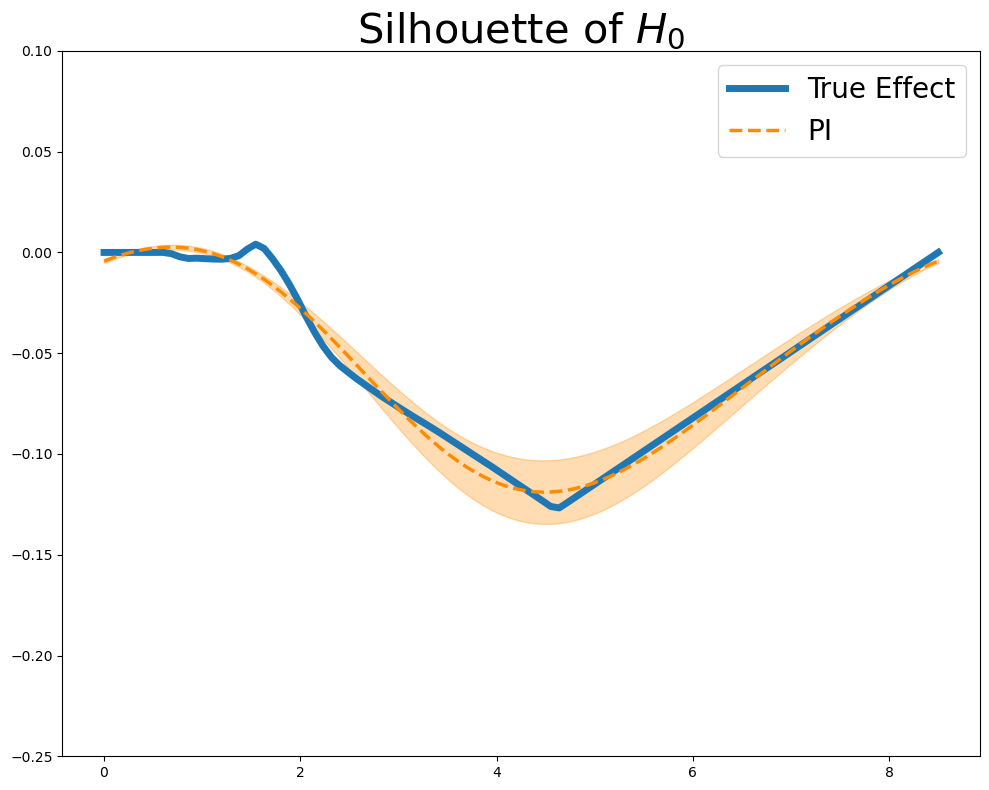

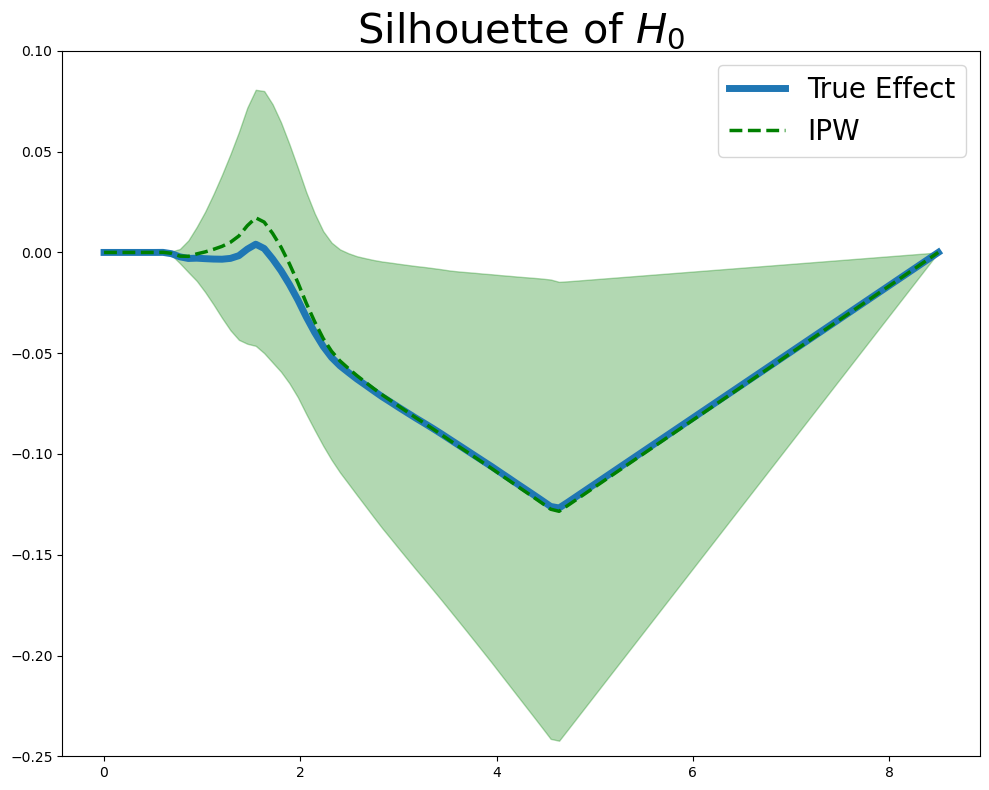

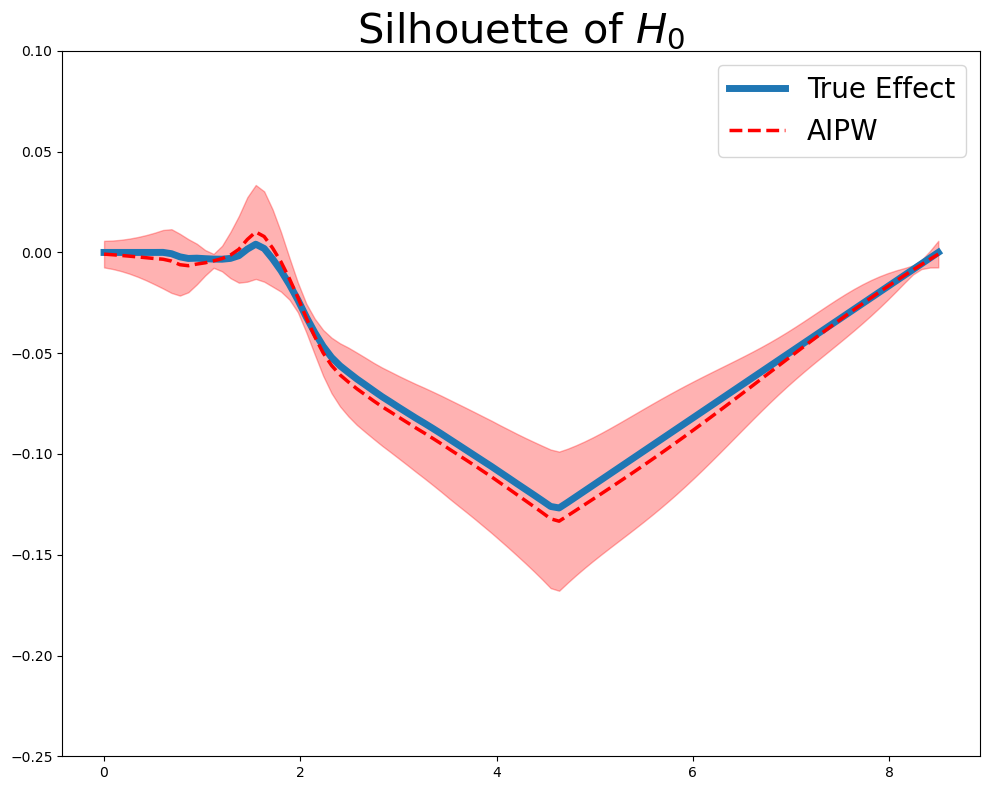

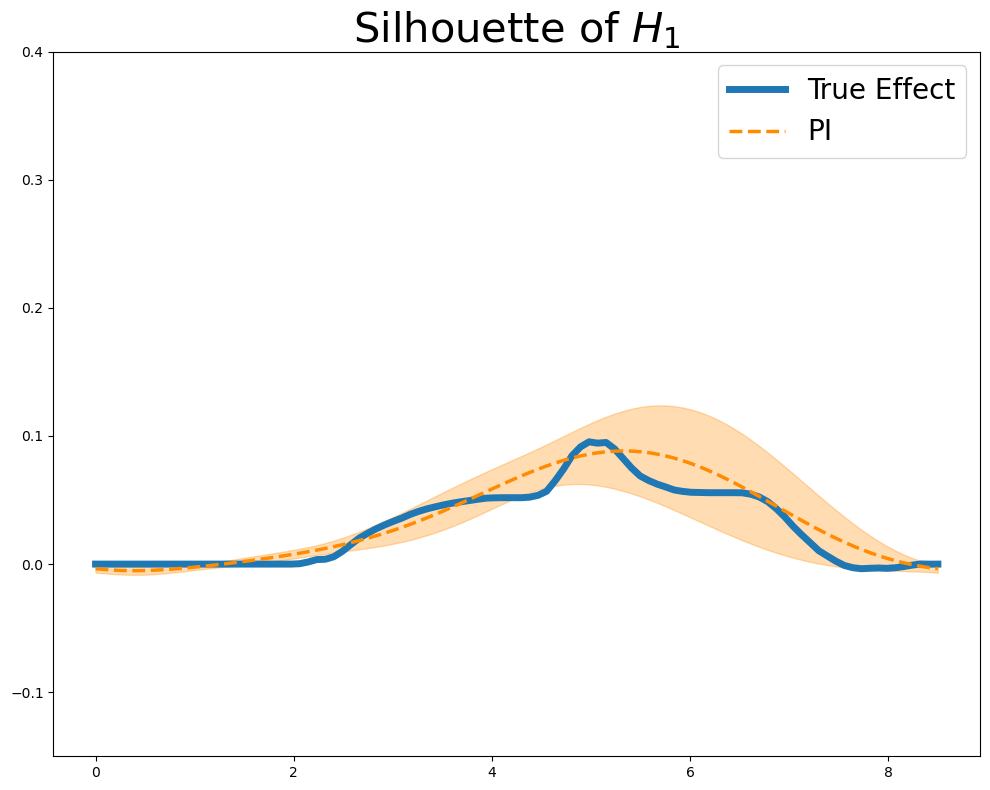

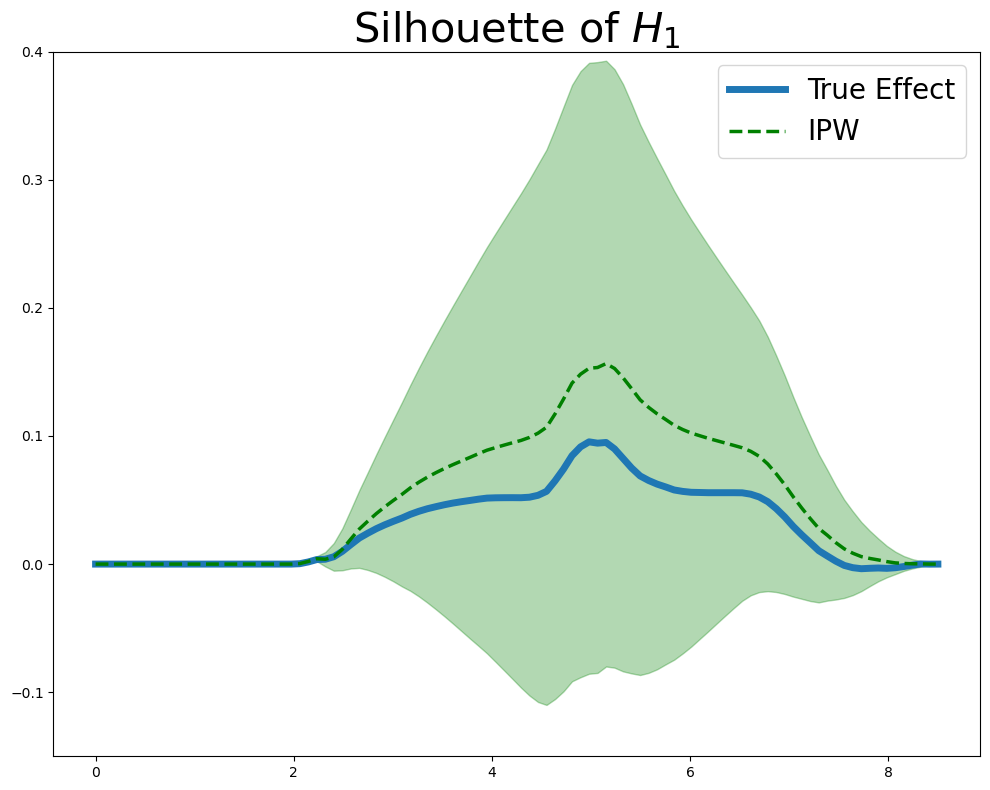

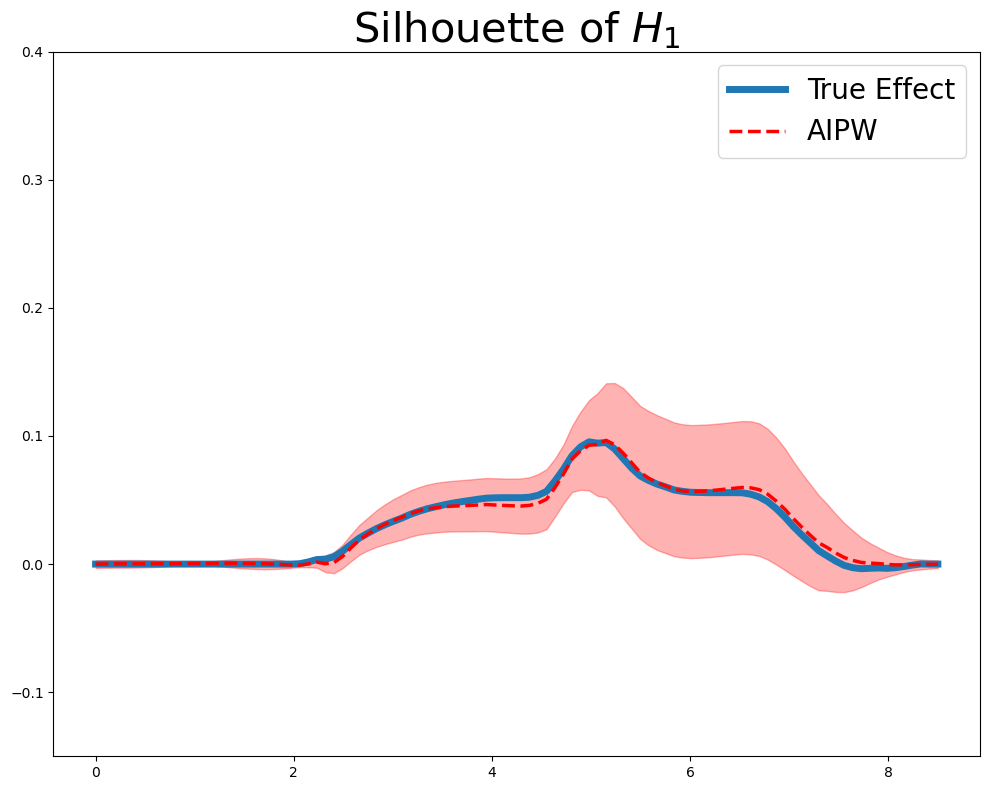

In [190]:
# H0
# plugin
plt.figure(figsize=(10,8))
plt.plot(tseq, true_effect[0], label="True Effect", lw=2*lw)
plt.plot(tseq, pi0_avg, label="PI", ls="--", lw=lw, color="darkorange")
plt.fill_between(tseq, pi0_avg - pi0_std, pi0_avg + pi0_std, alpha=0.3, color="darkorange")
plt.ylim(-0.25, 0.1)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_0$", size=30)
plt.tight_layout()
plt.show();

# ipw
plt.figure(figsize=(10,8))
plt.plot(tseq, true_effect[0], label="True Effect", lw=2*lw)
plt.plot(tseq, ipw0_avg, label="IPW", ls="--", lw=lw, color="green")
plt.fill_between(tseq, ipw0_avg - ipw0_std, ipw0_avg + ipw0_std, alpha=0.3, color="green")
plt.ylim(-0.25, 0.1)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_0$", size=30)
plt.tight_layout()
plt.show();

# aipw
plt.figure(figsize=(10,8))
plt.plot(tseq, true_effect[0], label="True Effect", lw=2*lw)
plt.plot(tseq, aipw0_avg, label="AIPW", ls="--", lw=lw, color="red")
plt.fill_between(tseq, aipw0_avg - aipw0_std, aipw0_avg + aipw0_std, alpha=0.3, color="red")
plt.ylim(-0.25, 0.1)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_0$", size=30)
plt.tight_layout()
plt.show();

# H1
# plugin
plt.figure(figsize=(10,8))
plt.plot(tseq, true_effect[1], label="True Effect", lw=2*lw)
plt.plot(tseq, pi1_avg, label="PI", ls="--", lw=lw, color="darkorange")
plt.fill_between(tseq, pi1_avg - pi1_std, pi1_avg + pi1_std, alpha=0.3, color="darkorange")
plt.ylim(-0.15, 0.4)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_1$", size=30)
plt.tight_layout()
plt.show();

# ipw
plt.figure(figsize=(10,8))
plt.plot(tseq, true_effect[1], label="True Effect", lw=2*lw)
plt.plot(tseq, ipw1_avg, label="IPW", ls="--", lw=lw, color="green")
plt.fill_between(tseq, ipw1_avg - ipw1_std, ipw1_avg + ipw1_std, alpha=0.3, color="green")
plt.ylim(-0.15, 0.4)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_1$", size=30)
plt.tight_layout()
plt.show();

# aipw
plt.figure(figsize=(10,8))
plt.plot(tseq, true_effect[1], label="True Effect", lw=2*lw)
plt.plot(tseq, aipw1_avg, label="AIPW", ls="--", lw=lw, color="red")
plt.fill_between(tseq, aipw1_avg - aipw1_std, aipw1_avg + aipw1_std, alpha=0.3, color="red")
plt.ylim(-0.15, 0.4)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_1$", size=30)
plt.tight_layout()
plt.show();

# Estimation under Model Misspecification

## Misspecification of $\pi$

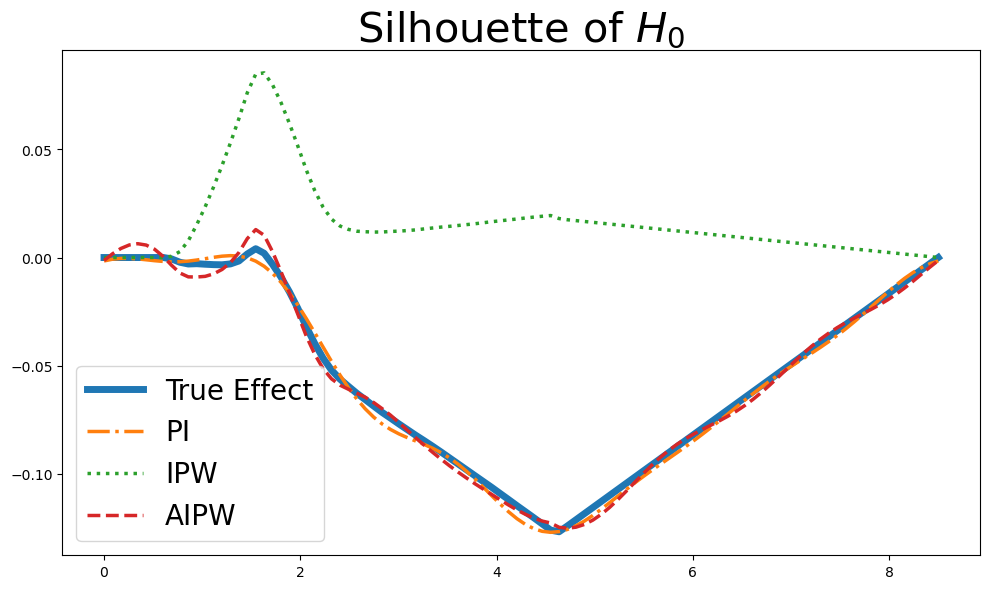

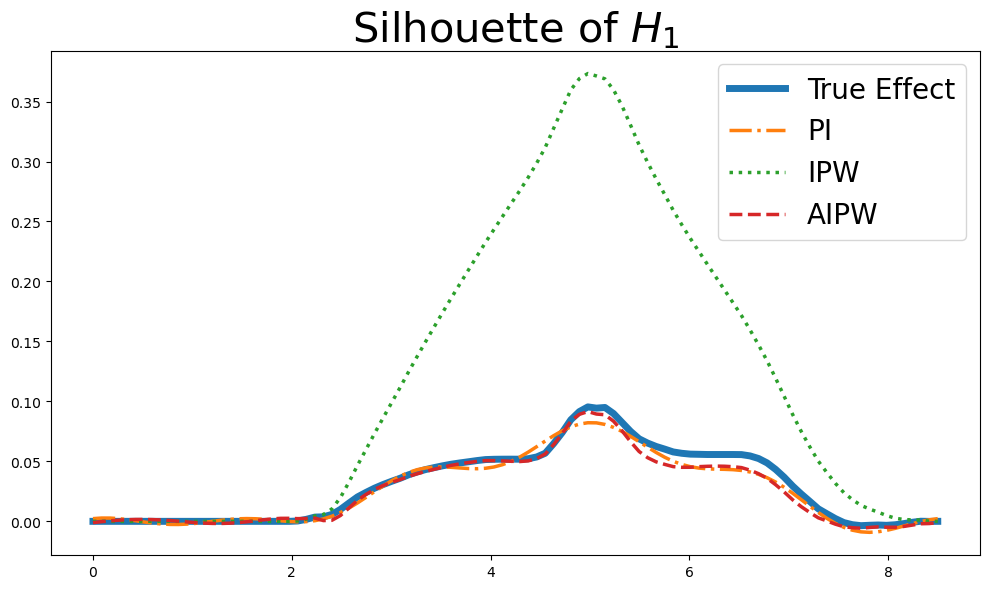

In [191]:
np.random.seed(42)

n_iter = 20
n_basis = 10

plugin0_list, ipw0_list, aipw0_list = [], [], []
plugin1_list, ipw1_list, aipw1_list = [], [], []

for i in range(n_iter):
    _, _, covariate = gen_covariate(mu1, mu2, Sigma, n) # generate covariates
    _, A = gen_trt_prob(covariate, beta)                # generate treatment

    # among those assigned to Y^1, 75% were data of non-infected and 25% were data of infected
    # change order of data such that the data of infected assigned to Y^1 have a higher probability of receiving treatment (makes estimation more challenging)
    size = int(n/2)
    subgroup2_idx = prob[-(n-size):].argsort() + size
    idx = np.concatenate([np.arange(int(size)), subgroup2_idx[-(n-size):]])
    covariate = covariate[idx]
    A = A[idx]
    observed_data = (potential_outcomes[range(n), A], A, covariate) # construct observed data

    # sample split
    phi1, phi2, A1, A2, X1, X2 = train_test_split(*observed_data, test_size=0.5, random_state=0, stratify=observed_data[1])   # stratify on A
    sample1 = (phi1, A1, X1)
    sample2 = (phi2, A2, X2)

    # plug-in
    # fit on sample 1, estimate on sample 2
    reg1 = fit_functional_regression((phi1, A1, X1), tseq, n_basis=n_basis)
    mu_hats1= [(mu0.predict(pd.DataFrame(X2))(tseq).squeeze(), mu1.predict(pd.DataFrame(X2))(tseq).squeeze()) for mu0, mu1 in reg1]
    plugin10, plugin11 = plugin_estimator(mu_hats1)
    # fit on sample 2, estimate on sample 1
    reg2 = fit_functional_regression((phi2, A2, X2), tseq, n_basis=n_basis)
    mu_hats2 = [(mu0.predict(pd.DataFrame(X1))(tseq).squeeze(), mu1.predict(pd.DataFrame(X1))(tseq).squeeze()) for mu0, mu1 in reg2]
    plugin20, plugin21 = plugin_estimator(mu_hats2)
    # average
    plugin0 = (plugin10 + plugin20) / 2  # homology dim 0
    plugin0_list.append(plugin0)
    plugin1 = (plugin11 + plugin21) / 2  # homology dim 1
    plugin1_list.append(plugin1)

    # ipw
    # fit on sample 1, estimate on sample 2
    pi_hat1 = LogisticRegression(fit_intercept=False, penalty=None).fit(X1[:, [0, 2]], A1).predict_proba(X2[:, [0, 2]])[:,1]
    ipw10, ipw11 = ipw_estimator(pi_hat1, (phi2, A2, X2))
    # fit on sample 2, estimate on sample 1
    pi_hat2 = LogisticRegression(fit_intercept=False, penalty=None).fit(X2[:, [0, 2]], A2).predict_proba(X1[:, [0, 2]])[:,1]
    ipw20, ipw21 = ipw_estimator(pi_hat2, (phi1, A1, X1))
    # average
    ipw0 = (ipw10 + ipw20) / 2  # homology dim 0
    ipw0_list.append(ipw0)
    ipw1 = (ipw11 + ipw21) / 2  # homology dim 1
    ipw1_list.append(ipw1)

    # aipw
    # fit on sample 1, estimate on sample 2
    aipw10, aipw11 = aipw_estimator(pi_hat1, mu_hats1, (phi2, A2, X2))
    # fit on sample 2, estimate on sample 1
    aipw20, aipw21 = aipw_estimator(pi_hat2, mu_hats2, (phi1, A1, X1))
    # average
    aipw0 = (aipw10 + aipw20) / 2     # homology dim 0
    aipw0_list.append(aipw0)
    aipw1 = (aipw11 + aipw21) / 2     # homology dim 1
    aipw1_list.append(aipw1)


# plot H0
ipw0_avg = np.array(ipw0_list).mean(axis=0)
ipw0_std = np.array(ipw0_list).std(axis=0)
pi0_avg = np.array(plugin0_list).mean(axis=0)
pi0_std = np.array(plugin0_list).std(axis=0)
aipw0_avg = np.array(aipw0_list).mean(axis=0)
aipw0_std = np.array(aipw0_list).std(axis=0)

plt.figure(figsize=(10,6))
plt.plot(tseq, true_effect[0], label="True Effect", lw=2*lw)
plt.plot(tseq, pi0_avg, label="PI", ls="-.", lw=lw)
plt.plot(tseq, ipw0_avg, label="IPW", ls=":", lw=lw)
plt.plot(tseq, aipw0_avg, label="AIPW", ls="--", lw=lw)
# plt.ylim(-0.15, 0.4)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_0$", size=30)
plt.tight_layout()
plt.show();

# plot H1
ipw1_avg = np.array(ipw1_list).mean(axis=0)
ipw1_std = np.array(ipw1_list).std(axis=0)
pi1_avg = np.array(plugin1_list).mean(axis=0)
pi1_std = np.array(plugin1_list).std(axis=0)
aipw1_avg = np.array(aipw1_list).mean(axis=0)
aipw1_std = np.array(aipw1_list).std(axis=0)

plt.figure(figsize=(10,6))
plt.plot(tseq, true_effect[1], label="True Effect", lw=2*lw)
plt.plot(tseq, pi1_avg, label="PI", ls="-.", lw=lw)
plt.plot(tseq, ipw1_avg, label="IPW", ls=":", lw=lw)
plt.plot(tseq, aipw1_avg, label="AIPW", ls="--", lw=lw)
# plt.ylim(-0.15, 0.4)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_1$", size=30)
plt.tight_layout()
plt.show();

### $L_1$ distance and Std.

In [192]:
# H0
# L1 distance between true effect and average estimated effect
l1_pi0 = numerical_integration(np.abs(true_effect[0] - pi0_avg), tseq)
l1_ipw0 = numerical_integration(np.abs(true_effect[0] - ipw0_avg), tseq)
l1_aipw0 = numerical_integration(np.abs(true_effect[0] - aipw0_avg), tseq)

print(f"H0 L1 dist: PI:{l1_pi0} IPW:{l1_ipw0} AIPW:{l1_aipw0}")

# covariance
cov_pi0 = np.cov(np.array(plugin0_list), rowvar=False)
cov_ipw0 = np.cov(np.array(ipw0_list), rowvar=False)
cov_aipw0 = np.cov(np.array(aipw0_list), rowvar=False)

print(f"H0 Std.: PI:{np.sqrt(cov_pi0.mean())} IPW:{np.sqrt(cov_ipw0.mean())} AIPW:{np.sqrt(cov_aipw0.mean())}")

# H1
# L1 distance between true effect and average estimated effect
l1_pi1 = numerical_integration(np.abs(true_effect[1] - pi1_avg), tseq)
l1_ipw1 = numerical_integration(np.abs(true_effect[1] - ipw1_avg), tseq)
l1_aipw1 = numerical_integration(np.abs(true_effect[1] - aipw1_avg), tseq)

print(f"H1 L1 dist: PI:{l1_pi1} IPW:{l1_ipw1} AIPW:{l1_aipw1}")

# covariance
cov_pi1 = np.cov(np.array(plugin1_list), rowvar=False)
cov_ipw1 = np.cov(np.array(ipw1_list), rowvar=False)
cov_aipw1 = np.cov(np.array(aipw1_list), rowvar=False)

print(f"H1 Std.: PI:{np.sqrt(cov_pi1.mean())} IPW:{np.sqrt(cov_ipw1.mean())} AIPW:{np.sqrt(cov_aipw1.mean())}")

H0 L1 dist: PI:0.020056416892565505 IPW:0.617962399291814 AIPW:0.023430033969842123
H0 Std.: PI:0.011325154736534853 IPW:0.03602420080976512 AIPW:0.011676293771121416
H1 L1 dist: PI:0.040220451617035684 IPW:0.7796269118820609 AIPW:0.034324609247990696
H1 Std.: PI:0.00865466741293319 IPW:0.04425923091232552 AIPW:0.008971952019309209


## Misspecification of $\mu$

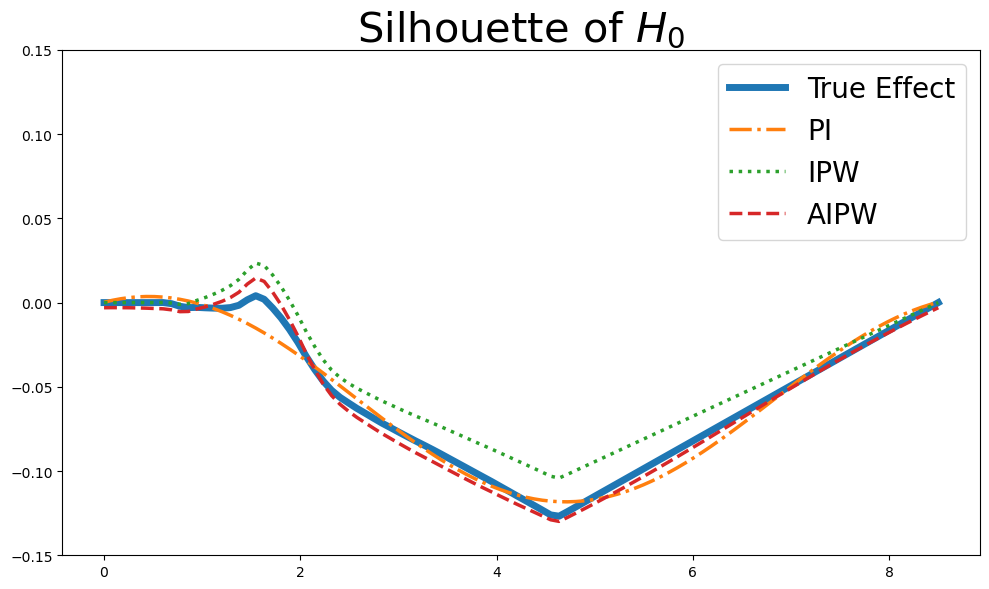

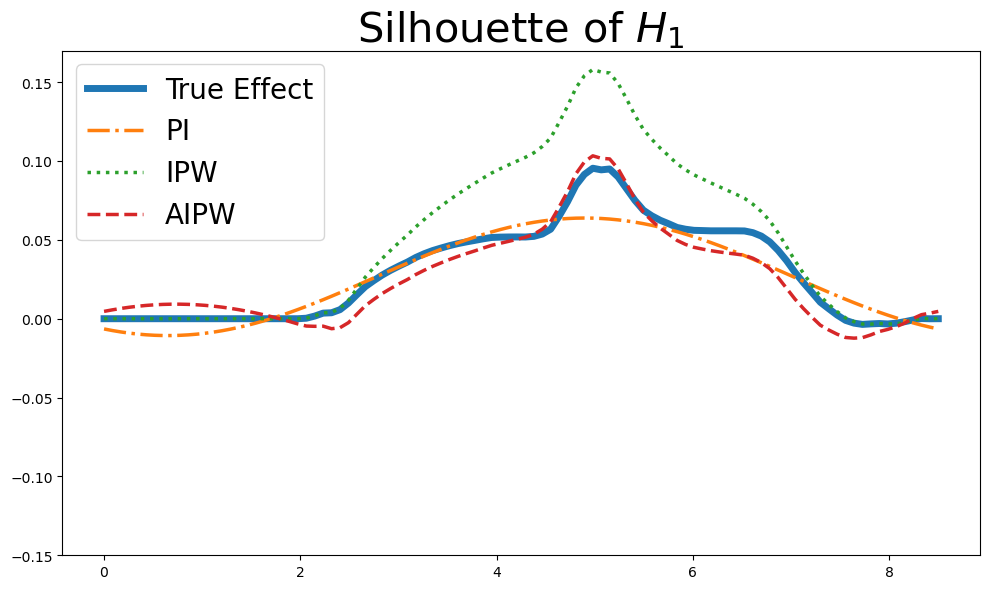

In [193]:
np.random.seed(42)

n_iter = 20
n_basis = 2

plugin0_list, ipw0_list, aipw0_list = [], [], []
plugin1_list, ipw1_list, aipw1_list = [], [], []

for i in range(n_iter):
    _, _, covariate = gen_covariate(mu1, mu2, Sigma, n) # generate covariates
    _, A = gen_trt_prob(covariate, beta)                # generate treatment
    
    # among those assigned to Y^1, 75% were data of non-infected and 25% were data of infected
    # change order of data such that the data of infected assigned to Y^1 have a higher probability of receiving treatment (makes estimation more challenging)
    size = int(n/2)
    subgroup2_idx = prob[-(n-size):].argsort() + size
    idx = np.concatenate([np.arange(int(size)), subgroup2_idx[-(n-size):]])
    covariate = covariate[idx]
    A = A[idx]
    observed_data = (potential_outcomes[range(n), A], A, covariate) # construct observed data

    # sample split
    phi1, phi2, A1, A2, X1, X2 = train_test_split(*observed_data, test_size=0.5, random_state=0, stratify=observed_data[1])   # stratify on A
    sample1 = (phi1, A1, X1)
    sample2 = (phi2, A2, X2)

    # plug-in
    # fit on sample 1, estimate on sample 2
    reg1 = fit_functional_regression((phi1, A1, X1), tseq, n_basis=n_basis)
    mu_hats1= [(mu0.predict(pd.DataFrame(X2))(tseq).squeeze(), mu1.predict(pd.DataFrame(X2))(tseq).squeeze()) for mu0, mu1 in reg1]
    plugin10, plugin11 = plugin_estimator(mu_hats1)
    # fit on sample 2, estimate on sample 1
    reg2 = fit_functional_regression((phi2, A2, X2), tseq, n_basis=n_basis)
    mu_hats2 = [(mu0.predict(pd.DataFrame(X1))(tseq).squeeze(), mu1.predict(pd.DataFrame(X1))(tseq).squeeze()) for mu0, mu1 in reg2]
    plugin20, plugin21 = plugin_estimator(mu_hats2)
    # average
    plugin0 = (plugin10 + plugin20) / 2  # homology dim 0
    plugin0_list.append(plugin0)
    plugin1 = (plugin11 + plugin21) / 2  # homology dim 1
    plugin1_list.append(plugin1)

    # ipw
    # fit on sample 1, estimate on sample 2
    pi_hat1 = LogisticRegression(fit_intercept=False, penalty=None).fit(np.hstack([X1, X1[:,[1]]*X1[:,[2]], X1[:,[0]]*X1[:,[2]]]), A1).predict_proba(np.hstack([X2, X2[:,[1]]*X2[:,[2]], X2[:,[0]]*X2[:,[2]]]))[:,1]
    ipw10, ipw11 = ipw_estimator(pi_hat1, (phi2, A2, X2))
    # fit on sample 2, estimate on sample 1
    pi_hat2 = LogisticRegression(fit_intercept=False, penalty=None).fit(np.hstack([X2, X2[:,[1]]*X2[:,[2]], X2[:,[0]]*X2[:,[2]]]), A2).predict_proba(np.hstack([X1, X1[:,[1]]*X1[:,[2]], X1[:,[0]]*X1[:,[2]]]))[:,1]
    ipw20, ipw21 = ipw_estimator(pi_hat2, (phi1, A1, X1))
    # average
    ipw0 = (ipw10 + ipw20) / 2  # homology dim 0
    ipw0_list.append(ipw0)
    ipw1 = (ipw11 + ipw21) / 2  # homology dim 1
    ipw1_list.append(ipw1)

    # aipw
    # fit on sample 1, estimate on sample 2
    aipw10, aipw11 = aipw_estimator(pi_hat1, mu_hats1, (phi2, A2, X2))
    # fit on sample 2, estimate on sample 1
    aipw20, aipw21 = aipw_estimator(pi_hat2, mu_hats2, (phi1, A1, X1))
    # average
    aipw0 = (aipw10 + aipw20) / 2     # homology dim 0
    aipw0_list.append(aipw0)
    aipw1 = (aipw11 + aipw21) / 2     # homology dim 1
    aipw1_list.append(aipw1)


# plot H0
ipw0_avg = np.array(ipw0_list).mean(axis=0)
ipw0_std = np.array(ipw0_list).std(axis=0)
pi0_avg = np.array(plugin0_list).mean(axis=0)
pi0_std = np.array(plugin0_list).std(axis=0)
aipw0_avg = np.array(aipw0_list).mean(axis=0)
aipw0_std = np.array(aipw0_list).std(axis=0)

plt.figure(figsize=(10,6))
plt.plot(tseq, true_effect[0], label="True Effect", lw=2*lw)
plt.plot(tseq, pi0_avg, label="PI", ls="-.", lw=lw)
plt.plot(tseq, ipw0_avg, label="IPW", ls=":", lw=lw)
plt.plot(tseq, aipw0_avg, label="AIPW", ls="--", lw=lw)
plt.ylim(-0.15, 0.15)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_0$", size=30)
plt.tight_layout()
plt.show();

# plot H1
ipw1_avg = np.array(ipw1_list).mean(axis=0)
ipw1_std = np.array(ipw1_list).std(axis=0)
pi1_avg = np.array(plugin1_list).mean(axis=0)
pi1_std = np.array(plugin1_list).std(axis=0)
aipw1_avg = np.array(aipw1_list).mean(axis=0)
aipw1_std = np.array(aipw1_list).std(axis=0)

plt.figure(figsize=(10,6))
plt.plot(tseq, true_effect[1], label="True Effect", lw=2*lw)
plt.plot(tseq, pi1_avg, label="PI", ls="-.", lw=lw)
plt.plot(tseq, ipw1_avg, label="IPW", ls=":", lw=lw)
plt.plot(tseq, aipw1_avg, label="AIPW", ls="--", lw=lw)
plt.ylim(-0.15, 0.17)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_1$", size=30)
plt.tight_layout()
plt.show();

### $L_1$ distance and Std.

In [194]:
# H0
# L1 distance between true effect and average estimated effect
l1_pi0 = numerical_integration(np.abs(true_effect[0] - pi0_avg), tseq)
l1_ipw0 = numerical_integration(np.abs(true_effect[0] - ipw0_avg), tseq)
l1_aipw0 = numerical_integration(np.abs(true_effect[0] - aipw0_avg), tseq)

print(f"H0 L1 dist: PI:{l1_pi0} IPW:{l1_ipw0} AIPW:{l1_aipw0}")

# covariance
cov_pi0 = np.cov(np.array(plugin0_list), rowvar=False)
cov_ipw0 = np.cov(np.array(ipw0_list), rowvar=False)
cov_aipw0 = np.cov(np.array(aipw0_list), rowvar=False)

print(f"H0 Std.: PI:{np.sqrt(cov_pi0.mean())} IPW:{np.sqrt(cov_ipw0.mean())} AIPW:{np.sqrt(cov_aipw0.mean())}")

# H1
# L1 distance between true effect and average estimated effect
l1_pi1 = numerical_integration(np.abs(true_effect[1] - pi1_avg), tseq)
l1_ipw1 = numerical_integration(np.abs(true_effect[1] - ipw1_avg), tseq)
l1_aipw1 = numerical_integration(np.abs(true_effect[1] - aipw1_avg), tseq)

print(f"H1 L1 dist: PI:{l1_pi1} IPW:{l1_ipw1} AIPW:{l1_aipw1}")

# covariance
cov_pi1 = np.cov(np.array(plugin1_list), rowvar=False)
cov_ipw1 = np.cov(np.array(ipw1_list), rowvar=False)
cov_aipw1 = np.cov(np.array(aipw1_list), rowvar=False)

print(f"H1 Std.: PI:{np.sqrt(cov_pi1.mean())} IPW:{np.sqrt(cov_ipw1.mean())} AIPW:{np.sqrt(cov_aipw1.mean())}")

H0 L1 dist: PI:0.04376358767815917 IPW:0.1029888751362431 AIPW:0.03380086841117293
H0 Std.: PI:0.011325154736534896 IPW:0.02831066538252635 AIPW:0.013897759910063593
H1 L1 dist: PI:0.06879345582884852 IPW:0.16245061333824287 AIPW:0.06841930340176959
H1 Std.: PI:0.008654667412933225 IPW:0.03563743002063605 AIPW:0.011120028556012893
